In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from fastai.tabular.all import *
from pathlib import Path

pd.options.display.float_format = '{:.2f}'.format
set_seed(42)

In [6]:
  os.getcwd()

'c:\\Users\\schitta\\Downloads\\ml-experiments\\experiments\\kaggle\\0326'

In [7]:
path = Path('playground-series-s6e3/')

In [8]:
path

Path('playground-series-s6e3')

In [33]:
df = pd.read_csv(path/'train.csv')
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [11]:
df.dtypes

id                    int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [15]:
# get str columns
df.select_dtypes(include='object').columns

C:\Users\schitta\AppData\Local\Temp\ipykernel_90188\2504915162.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [34]:
df['NoInternetService'] = (df['InternetService'] == 'No').astype(int)
df['FastInternetService'] = (df['InternetService'] == 'Fiber optic').astype(int)


In [35]:
df.drop('InternetService', axis=1, inplace=True)

In [36]:
for i in ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling']:
    if i in ['gender']:
        df[i] = df[i].map({'Male':1, 'Female':0}).astype(int)
    else:
        df[i] = (df[i] == 'Yes').astype(int)

In [38]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NoInternetService,FastInternetService
0,0,1,0,1,1,29,1,0,1,0,...,0,0,One year,1,Mailed check,60.10,1653.85,No,0,0
1,1,1,0,1,1,58,1,0,1,1,...,1,0,Two year,0,Credit card (automatic),69.50,3778.20,No,0,0
2,2,1,0,1,0,58,1,1,0,1,...,1,1,Month-to-month,1,Electronic check,100.40,5841.35,No,0,1
3,3,0,0,0,0,1,1,0,0,0,...,0,0,Month-to-month,1,Electronic check,69.70,70.70,Yes,0,1
4,4,0,0,0,0,1,1,0,0,0,...,0,0,Month-to-month,1,Electronic check,70.45,70.45,Yes,0,1


In [39]:
df.dtypes

id                       int64
gender                   int64
SeniorCitizen            int64
Partner                  int64
Dependents               int64
tenure                   int64
PhoneService             int64
MultipleLines            int64
OnlineSecurity           int64
OnlineBackup             int64
DeviceProtection         int64
TechSupport              int64
StreamingTV              int64
StreamingMovies          int64
Contract                   str
PaperlessBilling         int64
PaymentMethod              str
MonthlyCharges         float64
TotalCharges           float64
Churn                      str
NoInternetService        int64
FastInternetService      int64
dtype: object

In [40]:
cat_cols =  ['Contract', 'PaymentMethod']

for col in cat_cols:
    df[col] = df[col].astype('category')

df.dtypes

id                        int64
gender                    int64
SeniorCitizen             int64
Partner                   int64
Dependents                int64
tenure                    int64
PhoneService              int64
MultipleLines             int64
OnlineSecurity            int64
OnlineBackup              int64
DeviceProtection          int64
TechSupport               int64
StreamingTV               int64
StreamingMovies           int64
Contract               category
PaperlessBilling          int64
PaymentMethod          category
MonthlyCharges          float64
TotalCharges            float64
Churn                       str
NoInternetService         int64
FastInternetService       int64
dtype: object

In [41]:
df.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'NoInternetService', 'FastInternetService'],
      dtype='str')

In [42]:
df['Churn'].value_counts()/len(df)

Churn
No    0.77
Yes   0.23
Name: count, dtype: float64

In [43]:
import numpy as np

df.describe(include=(np.number))

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,NoInternetService,FastInternetService
count,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00,594194.00
mean,297096.50,0.50,0.11,0.52,0.30,36.58,0.94,0.46,0.28,0.34,0.35,0.28,0.40,0.41,0.62,65.87,2494.38,0.24,0.46
std,171529.18,0.50,0.32,0.50,0.46,25.06,0.24,0.50,0.45,0.47,0.48,0.45,0.49,0.49,0.49,31.07,2353.92,0.43,0.50
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,18.80,0.00,0.00
25%,148548.25,0.00,0.00,0.00,0.00,12.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,29.90,639.65,0.00,0.00
50%,297096.50,0.00,0.00,1.00,0.00,35.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,74.10,1433.65,0.00,0.00
75%,445644.75,1.00,0.00,1.00,1.00,62.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,90.80,4263.80,0.00,1.00
max,594193.00,1.00,1.00,1.00,1.00,72.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,8684.80,1.00,1.00


In [44]:
df.isna().sum()

id                     0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
NoInternetService      0
FastInternetService    0
dtype: int64

In [13]:
def summarize_categorical(df, target=None):
    cat_cols = df.select_dtypes(include="category").columns
    summaries = []

    for col in cat_cols:
        vc = df[col].value_counts(dropna=False)
        top = vc.index[0]
        freq = vc.iloc[0]
        nunique = df[col].nunique(dropna=False)
        missing = df[col].isna().mean()

        # Round percentages to 2 decimals
        value_pct = {k: round(v, 2) for k, v in (vc / len(df)).to_dict().items()}

        row = {
            "column": col,
            "nunique": nunique,
            "top": top,
            "freq": freq,
            "missing_pct": round(missing, 2),
            "value_distribution": vc.to_dict(),
            "value_pct_distribution": value_pct,
            "unique_values": list(vc.index),  # actual object values
        }

        if target is not None:
            row["target_mean_by_top"] = round(df[df[col] == top][target].mean(), 2)
            row["target_mean_by_value"] = {k: round(v, 2) for k, v in df.groupby(col, dropna=False)[target].mean().to_dict().items()}

        summaries.append(row)

    return pd.DataFrame(summaries)


In [11]:
df.select_dtypes(include="category").columns

Index(['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
       'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='str')

In [17]:
summarize_categorical(df)

,column,nunique,top,freq,missing_pct,value_distribution,value_pct_distribution,unique_values
0,gender,2,Female,298738,0.00,"{'Female': 298738, 'Male': 295456}","{'Female': 0.5, 'Male': 0.5}","[Female, Male]"
1,Partner,2,Yes,309554,0.00,"{'Yes': 309554, 'No': 284640}","{'Yes': 0.52, 'No': 0.48}","[Yes, No]"
2,Dependents,2,No,414362,0.00,"{'No': 414362, 'Yes': 179832}","{'No': 0.7, 'Yes': 0.3}","[No, Yes]"
3,PhoneService,2,Yes,557893,0.00,"{'Yes': 557893, 'No': 36301}","{'Yes': 0.94, 'No': 0.06}","[Yes, No]"
4,MultipleLines,3,No,283384,0.00,"{'No': 283384, 'Yes': 274509, 'No phone service': 36301}","{'No': 0.48, 'Yes': 0.46, 'No phone service': 0.06}","[No, Yes, No phone service]"
5,InternetService,3,Fiber optic,272386,0.00,"{'Fiber optic': 272386, 'DSL': 181081, 'No': 140727}","{'Fiber optic': 0.46, 'DSL': 0.3, 'No': 0.24}","[Fiber optic, DSL, No]"
6,OnlineSecurity,3,No,289474,0.00,"{'No': 289474, 'Yes': 163993, 'No internet service': 140727}","{'No': 0.49, 'Yes': 0.28, 'No internet service': 0.24}","[No, Yes, No internet service]"
7,OnlineBackup,3,No,250083,0.00,"{'No': 250083, 'Yes': 203384, 'No internet service': 140727}","{'No': 0.42, 'Yes': 0.34, 'No internet service': 0.24}","[No, Yes, No internet service]"
8,DeviceProtection,3,No,247377,0.00,"{'No': 247377, 'Yes': 206090, 'No internet service': 140727}","{'No': 0.42, 'Yes': 0.35, 'No internet service': 0.24}","[No, Yes, No internet service]"
9,TechSupport,3,No,288571,0.00,"{'No': 288571, 'Yes': 164896, 'No internet service': 140727}","{'No': 0.49, 'Yes': 0.28, 'No internet service': 0.24}","[No, Yes, No internet service]"


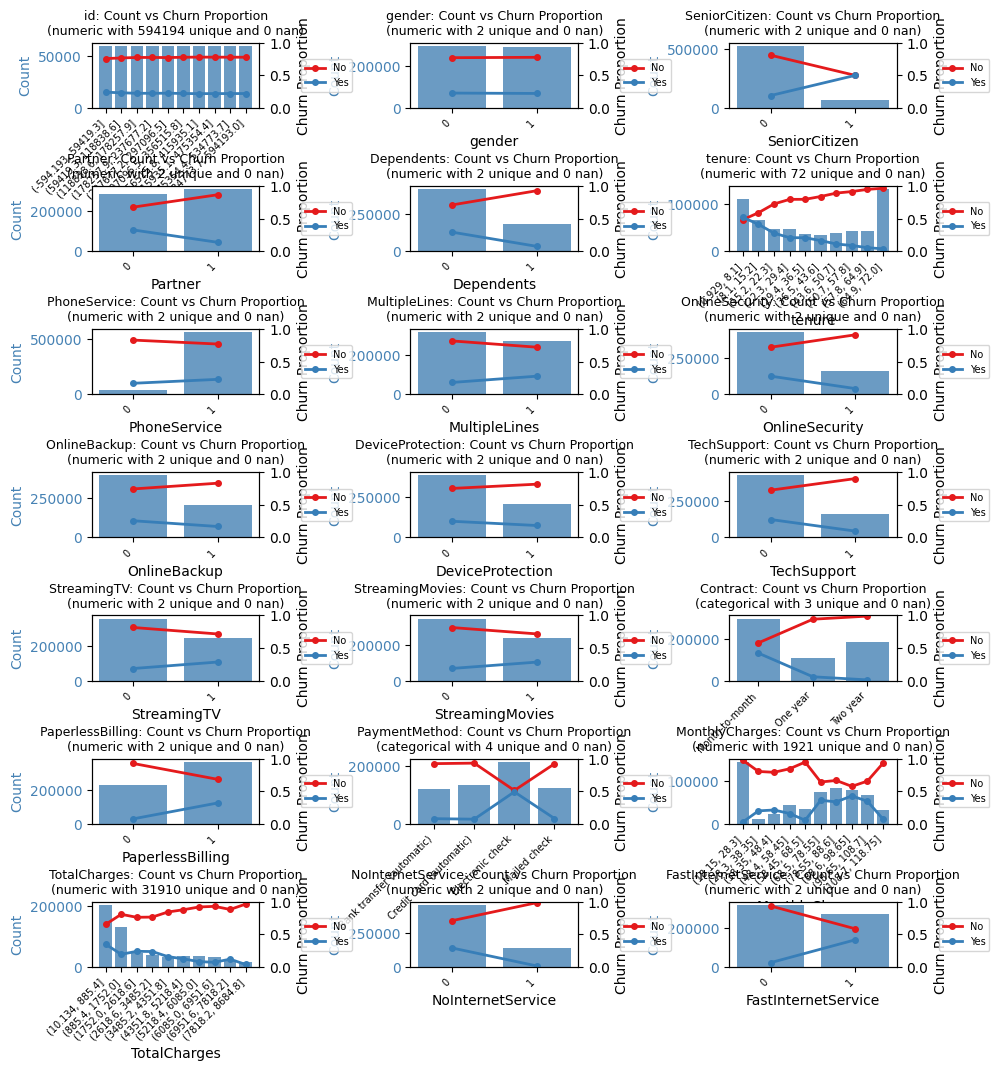

In [46]:
def plot_feature_vs_target(df, target_col=None, figsize=(14, 12), n_cols=3, bins=10, target_type='auto'):
    """
    Plot count distribution and optionally mean target value for each feature.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe containing features and optionally target
    target_col : str or None
        Name of the target column (e.g., 'exam_score'). 
        If None, only plots count distribution (for test data).
    figsize : tuple
        Figure size (width, height)
    n_cols : int
        Number of columns in subplot grid
    bins : int
        Number of bins for numeric features with many unique values
    target_type : str
        'auto', 'numeric', or 'categorical'. If 'auto', infers from data.
    """
    # Determine features to plot
    if target_col is not None:
        features = [col for col in df.columns if col != target_col]
    else:
        features = list(df.columns)
    
    # Determine target type
    if target_col is not None:
        if target_type == 'auto':
            if pd.api.types.is_numeric_dtype(df[target_col]) and df[target_col].nunique() > 10:
                target_type = 'numeric'
            else:
                target_type = 'categorical'
    
    n_features = len(features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, feature in enumerate(features):
        ax1 = axes[idx]
        
        n_unique = df[feature].nunique()
        n_nan = df[feature].isna().sum()
        
        # Determine if numeric or categorical
        is_numeric = pd.api.types.is_numeric_dtype(df[feature])
        
        if is_numeric and n_unique > 15:
            # Bin numeric features with many unique values
            df_temp = df[[feature]].dropna()
            df_temp['binned'] = pd.cut(df_temp[feature], bins=bins)
            grouped = df_temp.groupby('binned', observed=True).agg(
                count=(feature, 'size')
            ).reset_index()
            grouped['label'] = grouped['binned'].astype(str)
            feature_type = f"numeric with {n_unique} unique"
            
            # Add target stats if available
            if target_col is not None:
                df_with_target = df[[feature, target_col]].dropna()
                df_with_target['binned'] = pd.cut(df_with_target[feature], bins=bins)
                if target_type == 'numeric':
                    target_grouped = df_with_target.groupby('binned', observed=True).agg(
                        mean_target=(target_col, 'mean')
                    ).reset_index()
                    grouped = grouped.merge(target_grouped, on='binned', how='left')
                else:
                    # For categorical: compute proportion of each target class
                    target_grouped = df_with_target.groupby('binned', observed=True)[target_col].value_counts(normalize=True).unstack(fill_value=0)
                    target_grouped = target_grouped.reset_index()
                    grouped = grouped.merge(target_grouped, on='binned', how='left')
        else:
            # Categorical or numeric with few unique values
            grouped = df.groupby(feature, dropna=False).size().reset_index(name='count')
            grouped['label'] = grouped[feature].astype(str)
            feature_type = f"categorical with {n_unique} unique" if not is_numeric else f"numeric with {n_unique} unique"
            
            # Add target stats if available
            if target_col is not None:
                if target_type == 'numeric':
                    target_grouped = df.groupby(feature, dropna=False)[target_col].mean().reset_index()
                    target_grouped.columns = [feature, 'mean_target']
                    grouped = grouped.merge(target_grouped, on=feature, how='left')
                else:
                    target_grouped = df.groupby(feature, dropna=False)[target_col].value_counts(normalize=True).unstack(fill_value=0)
                    target_grouped = target_grouped.reset_index()
                    grouped = grouped.merge(target_grouped, on=feature, how='left')
        
        # Plot bar chart for counts
        x_pos = range(len(grouped))
        ax1.bar(x_pos, grouped['count'], color='steelblue', alpha=0.8)
        ax1.set_xlabel(feature)
        ax1.set_ylabel('Count', color='steelblue')
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(grouped['label'], rotation=45, ha='right', fontsize=7)
        
        # Create secondary y-axis for target ONLY if target_col is provided
        if target_col is not None:
            ax2 = ax1.twinx()
            if target_type == 'numeric':
                ax2.plot(x_pos, grouped['mean_target'], color='orange', marker='o', 
                         linewidth=2, markersize=6)
                ax2.set_ylabel(f'Mean {target_col}', color='orange')
                ax2.tick_params(axis='y', labelcolor='orange')
                title_suffix = f'Count vs Mean {target_col}'
            else:
                # Plot proportion lines for each target class
                target_classes = [c for c in grouped.columns if c not in ['count', 'label', feature, 'binned']]
                colors = plt.cm.Set1(range(len(target_classes)))
                for i, cls in enumerate(target_classes):
                    ax2.plot(x_pos, grouped[cls], marker='o', linewidth=2, markersize=4, 
                             color=colors[i], label=str(cls))
                ax2.set_ylabel(f'{target_col} Proportion', color='black')
                ax2.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), borderaxespad=0, fontsize=7, frameon=True)
                ax2.set_ylim(0, 1)
                title_suffix = f'Count vs {target_col} Proportion'
        else:
            title_suffix = 'Count Distribution'
        
        # Title with feature info
        ax1.set_title(f'{feature}: {title_suffix}\n({feature_type} and {n_nan} nan)', 
                      fontsize=9)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    fig.subplots_adjust(hspace=1.2, wspace=0.9, right=0.7)
    plt.show()
    
    return fig


f = plot_feature_vs_target(df, target_col='Churn', target_type='categorical')

In [50]:
df[['SeniorCitizen','Churn']].value_counts()

SeniorCitizen  Churn
0              No       426499
               Yes       99896
1              Yes       33921
               No        33878
Name: count, dtype: int64

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def _cramers_v(x, y):
    # Cramer's V for categorical-categorical
    confusion = pd.crosstab(x, y)
    if confusion.size == 0:
        return np.nan
    chi2 = scipy.stats.chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if n == 0:
        return np.nan
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1) or 1)))

def _correlation_ratio(categories, measurements):
    # Correlation ratio (eta) for categorical-numeric
    cat = pd.Series(categories).astype('category')
    meas = pd.Series(measurements)
    if meas.nunique() <= 1:
        return np.nan
    groups = [meas[cat == c] for c in cat.cat.categories]
    n = sum(len(g) for g in groups)
    if n == 0:
        return np.nan
    grand_mean = meas.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups if len(g) > 0)
    ss_total = ((meas - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    return np.sqrt(ss_between / ss_total)

def plot_feature_associations(df, figsize=(12, 10), method='spearman', cat_threshold=15):
    """
    Plot association matrices between independent variables (numeric/categorical/mixed).
    - Numeric vs Numeric: correlation (method)
    - Categorical vs Categorical: Cramer's V
    - Numeric vs Categorical: correlation ratio (eta)
    """
    cols = list(df.columns)
    n = len(cols)
    assoc = pd.DataFrame(np.nan, index=cols, columns=cols)

    def is_categorical(s):
        return (s.dtype == 'object') or (s.dtype == 'category') or (s.nunique(dropna=True) <= cat_threshold)

    for i, col_i in enumerate(cols):
        for j, col_j in enumerate(cols):
            if i > j:
                continue
            x = df[col_i]
            y = df[col_j]

            cat_i = is_categorical(x)
            cat_j = is_categorical(y)

            if i == j:
                assoc.iloc[i, j] = 1.0
            elif not cat_i and not cat_j:
                # numeric-numeric
                assoc.iloc[i, j] = x.corr(y, method=method)
                assoc.iloc[j, i] = assoc.iloc[i, j]
            elif cat_i and cat_j:
                # categorical-categorical
                assoc.iloc[i, j] = _cramers_v(x, y)
                assoc.iloc[j, i] = assoc.iloc[i, j]
            else:
                # mixed
                if cat_i:
                    assoc.iloc[i, j] = _correlation_ratio(x, y)
                else:
                    assoc.iloc[i, j] = _correlation_ratio(y, x)
                assoc.iloc[j, i] = assoc.iloc[i, j]

    # Heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(assoc, vmin=0, vmax=1, cmap='viridis', square=True, cbar_kws={'label': 'Association Strength'})
    plt.title('Feature Association Matrix (mixed types)')
    plt.tight_layout()
    plt.show()

    return assoc


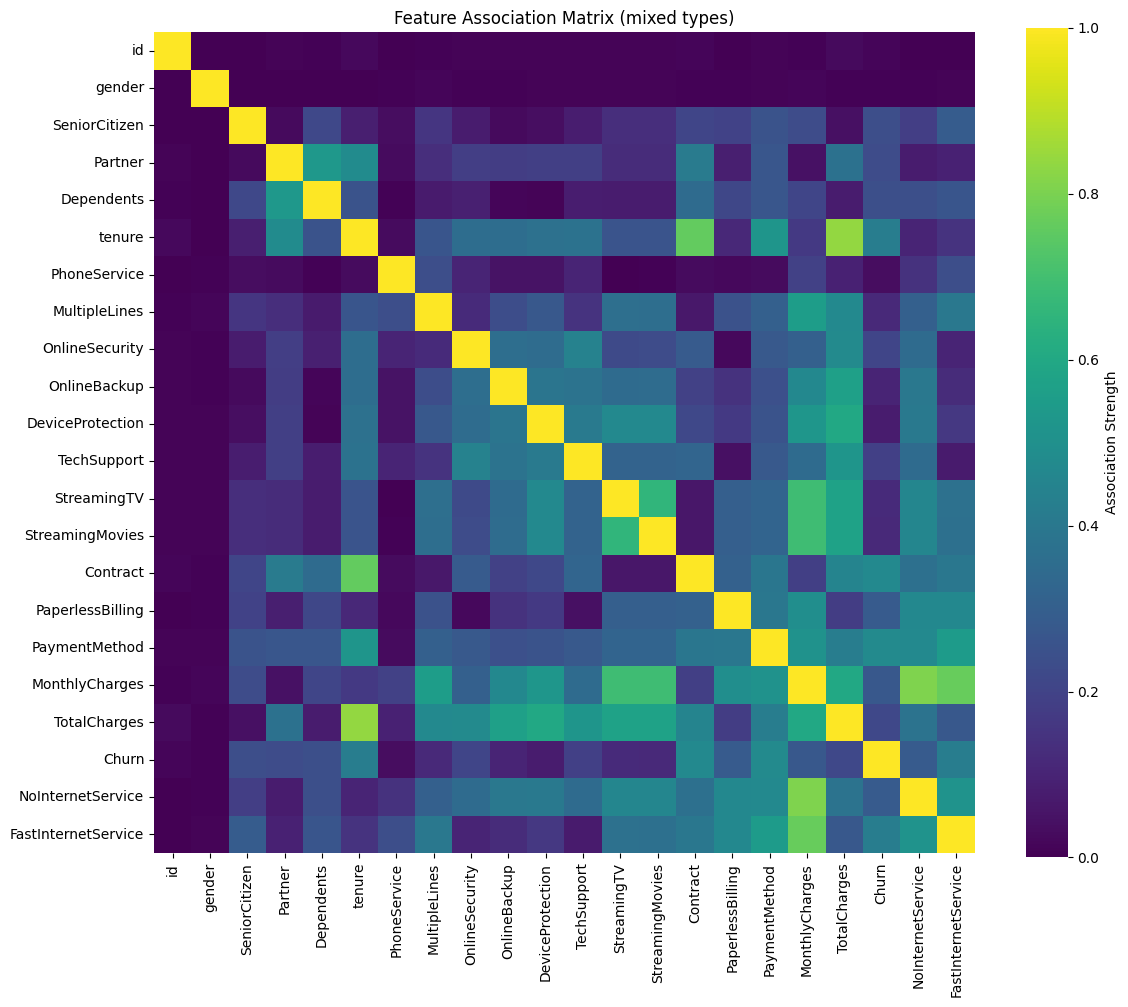

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NoInternetService,FastInternetService
id,1.00,0.00,0.00,0.01,0.00,0.02,0.00,0.01,0.01,0.01,...,0.01,0.01,0.01,0.00,0.01,0.01,0.02,0.01,0.00,0.00
gender,0.00,1.00,0.00,0.00,0.00,0.00,0.01,0.01,0.01,0.01,...,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
SeniorCitizen,0.00,0.00,1.00,0.03,0.22,0.08,0.03,0.15,0.08,0.02,...,0.13,0.13,0.20,0.20,0.26,0.23,0.04,0.24,0.18,0.29
Partner,0.01,0.00,0.03,1.00,0.53,0.48,0.03,0.13,0.18,0.18,...,0.12,0.12,0.41,0.08,0.27,0.05,0.37,0.23,0.08,0.09
Dependents,0.00,0.00,0.22,0.53,1.00,0.26,0.00,0.07,0.09,0.01,...,0.08,0.08,0.35,0.21,0.27,0.20,0.08,0.24,0.24,0.26
tenure,0.02,0.00,0.08,0.48,0.26,1.00,0.03,0.26,0.35,0.36,...,0.26,0.26,0.76,0.11,0.52,0.17,0.84,0.42,0.10,0.14
PhoneService,0.00,0.01,0.03,0.03,0.00,0.03,1.00,0.24,0.10,0.05,...,0.00,0.01,0.03,0.02,0.03,0.19,0.09,0.03,0.14,0.23
MultipleLines,0.01,0.01,0.15,0.13,0.07,0.26,0.24,1.00,0.12,0.23,...,0.36,0.36,0.06,0.25,0.30,0.55,0.47,0.11,0.30,0.40
OnlineSecurity,0.01,0.01,0.08,0.18,0.09,0.35,0.10,0.12,1.00,0.36,...,0.23,0.23,0.28,0.02,0.27,0.30,0.47,0.20,0.34,0.10
OnlineBackup,0.01,0.01,0.02,0.18,0.01,0.36,0.05,0.23,0.36,1.00,...,0.35,0.35,0.19,0.14,0.24,0.47,0.56,0.10,0.40,0.12


In [48]:
plot_feature_associations(df)

In [51]:
FEATURES = list( df.columns[1:-1] )
print(f"There are {len(FEATURES)} features:")
print(FEATURES)

There are 20 features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'NoInternetService']


In [28]:
df.dtypes

id                            int64
Age                           int64
Sex                        category
Chest pain type            category
BP                            int64
Cholesterol                   int64
FBS over 120               category
EKG results                category
Max HR                        int64
Exercise angina            category
ST depression               float64
Slope of ST                category
Number of vessels fluro    category
Thallium                   category
Heart Disease              category
dtype: object

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score


In [ ]:
df.isna().sum()

In [ ]:

df.describe(include=(np.number))

In [ ]:
df.columns

In [ ]:
df.select_dtypes(include='number').columns


In [ ]:
df.select_dtypes(include='object').columns


In [31]:
df.dtypes

id                            int64
Age                           int64
Sex                        category
Chest pain type            category
BP                            int64
Cholesterol                   int64
FBS over 120               category
EKG results                category
Max HR                        int64
Exercise angina            category
ST depression               float64
Slope of ST                category
Number of vessels fluro    category
Thallium                   category
Heart Disease              category
dtype: object

In [54]:
df.select_dtypes(include='category').columns

Index(['Contract', 'PaymentMethod'], dtype='str')

In [53]:
df.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'NoInternetService', 'FastInternetService'],
      dtype='str')

## simple logistic regression baseline

In [71]:
from sklearn.model_selection import train_test_split                                      
from sklearn.linear_model import LogisticRegression                                     
from sklearn.preprocessing import OneHotEncoder, StandardScaler                           
from sklearn.compose import ColumnTransformer                                           
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
      def fit(self, X, y=None):
          return self

      def transform(self, X):
          X = X.copy()
          X.drop(['id','Churn'], axis=1, inplace=True, errors='ignore')
          X['NoInternetService'] = (X['InternetService'] == 'No').astype(int)
          X['FastInternetService'] = (X['InternetService'] == 'Fiber optic').astype(int)
          X.drop('InternetService', axis=1, inplace=True)
          for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']:
              if col == 'gender':
                  X[col] = X[col].map({'Male': 1, 'Female': 0}).astype(int)
              else:
                  X[col] = (X[col] == 'Yes').astype(int)
          return X
      
# update below 
# cat_cols = ['Contract', 'PaymentMethod'] 
cont_cols =     ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'PaperlessBilling',  'MonthlyCharges',
       'TotalCharges', 'NoInternetService', 'FastInternetService']
df = pd.read_csv(path/'train.csv')
X = df
y = df['Churn']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2,
random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), cont_cols),
])

model = Pipeline([
    ('feat_eng', FeatureEngineer()),
    ('prep', preprocessor),
    ('lr', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_eng', ...), ('prep', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [56]:

# Get probabilities
train_probs = model.predict_proba(X_train)[:,1]
val_probs = model.predict_proba(X_valid)[:,1]

# Evaluate
print(f"Train Accuracy: {accuracy_score(y_train, model.predict(X_train)):.4f}")
print(f"Val Accuracy: {accuracy_score(y_valid, model.predict(X_valid)):.4f}")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs):.4f}")

Train Accuracy: 0.8546
Val Accuracy: 0.8544
Train ROC-AUC: 0.9079
Val ROC-AUC: 0.9084


In [94]:
# get coefficients by feature name
feature_names = model.named_steps['prep'].get_feature_names_out()
coefficients = model.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df.sort_values('coefficient', key=abs, ascending=False)

,feature,coefficient
3,cat__Chest pain type_4,2.24
14,cat__Thallium_7,1.95
12,cat__Number of vessels fluro_3,1.90
11,cat__Number of vessels fluro_2,1.84
13,cat__Thallium_6,1.43
7,cat__Exercise angina_1,1.19
10,cat__Number of vessels fluro_1,1.07
0,cat__Sex_1,1.05
8,cat__Slope of ST_2,0.91
9,cat__Slope of ST_3,0.88


In [58]:
model.classes_

array(['No', 'Yes'], dtype=object)

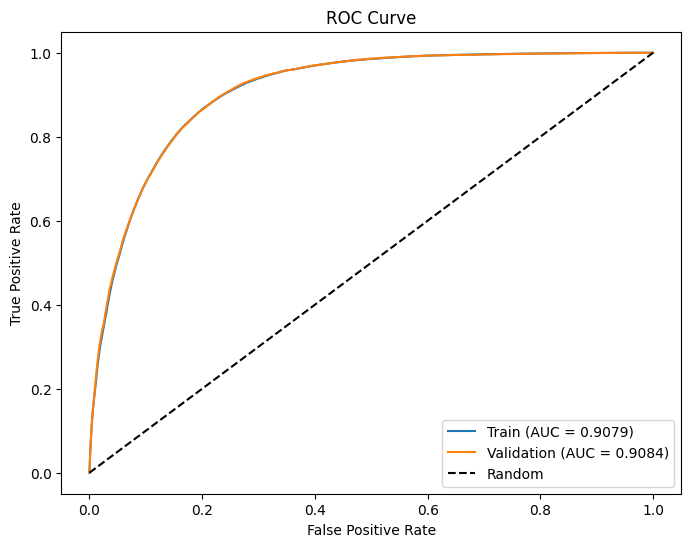

In [59]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Compute ROC curve and AUC for train
fpr_train, tpr_train, _ = roc_curve(y_train, train_probs, pos_label='Yes')
auc_train = auc(fpr_train, tpr_train)

# Compute ROC curve and AUC for validation
fpr_val, tpr_val, _ = roc_curve(y_valid, val_probs, pos_label='Yes')
auc_val = auc(fpr_val, tpr_val)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {auc_train:.4f})')
plt.plot(fpr_val, tpr_val, label=f'Validation (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## submission code

In [27]:
tst_df = pd.read_csv(path/'test.csv')

In [77]:
tst_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.80,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.00,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.00,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.90,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.80,2,0,7


In [78]:
len(tst_df)

270000

In [60]:
tst_df.isna().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

In [84]:
preds = model.predict_proba(tst_df[cat_cols + cont_cols])[:,1]

In [85]:
preds.shape

(270000,)

In [87]:
preds.squeeze()

array([0.8955659 , 0.00494145, 0.98942569, ..., 0.05195947, 0.25232796,
       0.02671106], shape=(270000,))

In [ ]:
preds[:5]

In [88]:
tst_df['Heart Disease'] = preds.squeeze()
sub_df = tst_df[['id','Heart Disease']]
sub_df.to_csv('baseline_submission_simplelogistic.csv', index=False)

##cv for simple logistic regression

In [ ]:

# cont_cols =     ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
#        'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
#        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
#         'PaperlessBilling',  'MonthlyCharges',
#        'TotalCharges', 'NoInternetService', 'FastInternetService']


# X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2,
# random_state=42, stratify=y)

# preprocessor = ColumnTransformer([
#     ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
#     ('num', StandardScaler(), cont_cols),
# ])

# model = Pipeline([
#     ('feat_eng', FeatureEngineer()),
#     ('prep', preprocessor),
#     ('lr', LogisticRegression(max_iter=1000))
# ])

# model.fit(X_train, y_train)

In [73]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score

# CV evaluation of simple logistic regression
N_FOLDS_CV = 5
skf_cv = StratifiedKFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=42)

df = pd.read_csv(path/'train.csv')
y = df['Churn']

y_bin = (y == 'Yes').astype(int)
X_full = df

oof_probs_lr = np.zeros(len(X_full))

for fold_idx, (train_idx, val_idx) in enumerate(skf_cv.split(X_full, y_bin)):
    X_fold_train = X_full.iloc[train_idx]
    y_fold_train = y.iloc[train_idx]
    X_fold_val = X_full.iloc[val_idx]
    y_fold_val = y.iloc[val_idx]

    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), cont_cols),
    ])

    fold_model = Pipeline([
        ('feat_eng', FeatureEngineer()),
        ('prep', preprocessor),
        ('lr', LogisticRegression(max_iter=1000))
    ])
        
    fold_model.fit(X_fold_train, y_fold_train)
    oof_probs_lr[val_idx] = fold_model.predict_proba(X_fold_val)[:, 1]
    
    fold_auc = roc_auc_score((y_fold_val == 'Yes').astype(int), oof_probs_lr[val_idx])
    fold_acc = accuracy_score(y_fold_val, fold_model.predict(X_fold_val))
    print(f"Fold {fold_idx+1}/{N_FOLDS_CV} — AUC: {fold_auc:.4f}, Acc: {fold_acc:.4f}")

# Overall OOF metrics
oof_auc = roc_auc_score(y_bin, oof_probs_lr)
oof_preds_binary = (oof_probs_lr >= 0.5).astype(int)
oof_acc = accuracy_score(y_bin, oof_preds_binary)
print(f"\n{'='*50}")
print(f"Overall OOF ROC-AUC: {oof_auc:.4f}")
print(f"Overall OOF Accuracy: {oof_acc:.4f}")

# Train on full training data and predict on test set
preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), cont_cols),
    ])

full_model = Pipeline([
    ('feat_eng', FeatureEngineer()),
    ('prep', preprocessor),
    ('lr', LogisticRegression(max_iter=1000))
])

full_model.fit(X_full, y)

# Full train metrics
full_train_probs = full_model.predict_proba(X_full)[:, 1]
print(f"\nFull Train ROC-AUC: {roc_auc_score(y_bin, full_train_probs):.4f}")
full_preds_binary = (full_model.predict(X_full) == 'Yes').astype(int)
print(f"Full Train Accuracy: {accuracy_score(y_bin, full_preds_binary):.4f}")


Fold 1/5 — AUC: 0.9075, Acc: 0.8530
Fold 2/5 — AUC: 0.9089, Acc: 0.8551
Fold 3/5 — AUC: 0.9081, Acc: 0.8548
Fold 4/5 — AUC: 0.9091, Acc: 0.8558
Fold 5/5 — AUC: 0.9062, Acc: 0.8539

Overall OOF ROC-AUC: 0.9079
Overall OOF Accuracy: 0.8545

Full Train ROC-AUC: 0.9080
Full Train Accuracy: 0.8545


In [74]:
tst_df_cv.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [75]:

# Test submission
tst_df_cv = pd.read_csv(path/'test.csv')

tst_preds_cv = full_model.predict_proba(tst_df_cv)[:, 1]

sub_df_cv = pd.DataFrame({'id': tst_df_cv['id'], 'Churn': tst_preds_cv})
sub_df_cv.to_csv('submission_simple_logistic_cv.csv', index=False)
print(f"\nSubmission shape: {sub_df_cv.shape}")
print(sub_df_cv.head())


Submission shape: (254655, 2)
       id  Churn
0  594194   0.05
1  594195   0.00
2  594196   0.12
3  594197   0.00
4  594198   0.50


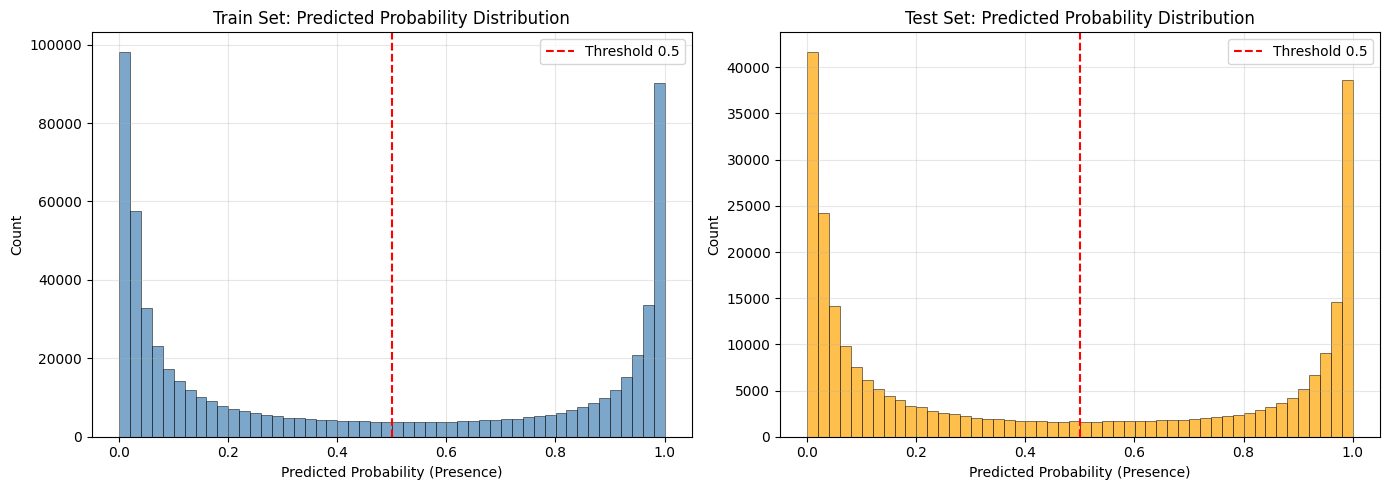

=== Train Predicted Probabilities ===
Mean: 0.4483, Std: 0.4049
Min: 0.0004, Max: 1.0000
% > 0.5: 43.72%

=== Test Predicted Probabilities ===
Mean: 0.4499, Std: 0.4047
Min: 0.0005, Max: 1.0000
% > 0.5: 43.92%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train predicted probabilities (from CV full model)
axes[0].hist(full_train_probs, bins=50, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Predicted Probability (Presence)')
axes[0].set_ylabel('Count')
axes[0].set_title('Train Set: Predicted Probability Distribution')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test predicted probabilities
axes[1].hist(tst_preds_cv, bins=50, alpha=0.7, color='orange', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Predicted Probability (Presence)')
axes[1].set_ylabel('Count')
axes[1].set_title('Test Set: Predicted Probability Distribution')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
print("=== Train Predicted Probabilities ===")
print(f"Mean: {full_train_probs.mean():.4f}, Std: {full_train_probs.std():.4f}")
print(f"Min: {full_train_probs.min():.4f}, Max: {full_train_probs.max():.4f}")
print(f"% > 0.5: {(full_train_probs > 0.5).mean():.2%}")

print(f"\n=== Test Predicted Probabilities ===")
print(f"Mean: {tst_preds_cv.mean():.4f}, Std: {tst_preds_cv.std():.4f}")
print(f"Min: {tst_preds_cv.min():.4f}, Max: {tst_preds_cv.max():.4f}")
print(f"% > 0.5: {(tst_preds_cv > 0.5).mean():.2%}")

In [ ]:
#can you plot distrubtion of predicted probability on train and test data?

# diagnosis

## check how good is calibration for simple lr model above 


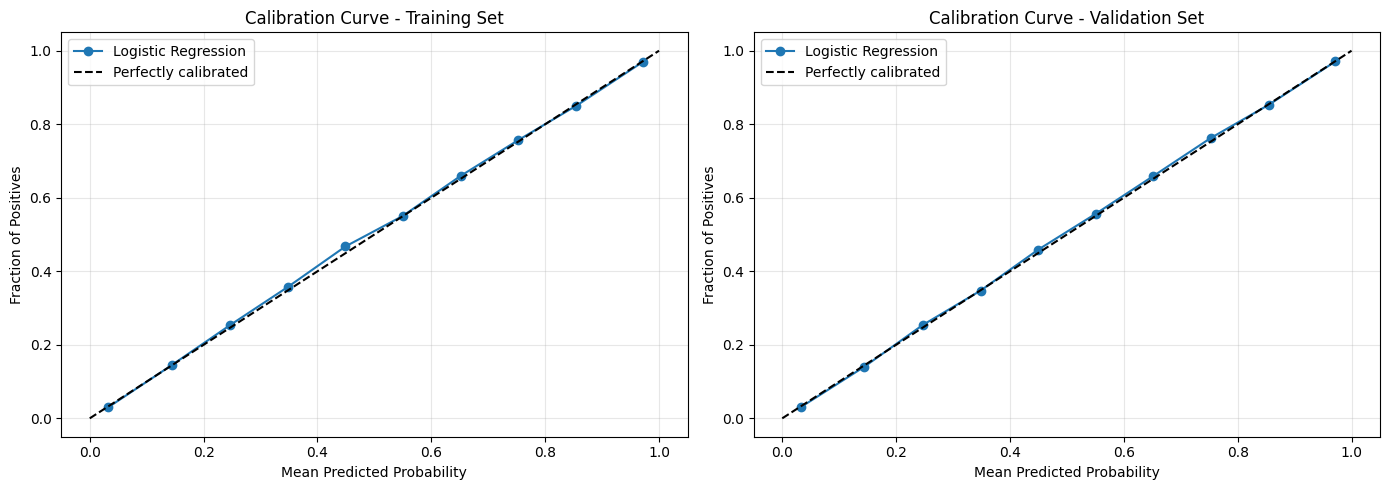

Brier Score (Train): 0.0837
Brier Score (Valid): 0.0827


In [106]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

import matplotlib.pyplot as plt

# Plot calibration curves for train and validation sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert categorical labels to binary (Presence=1, Absence=0)
y_train_binary = (y_train == 'Presence').astype(int)
y_valid_binary = (y_valid == 'Presence').astype(int)

# Calibration curve for training set
prob_true_train, prob_pred_train = calibration_curve(y_train_binary, train_probs, n_bins=10)
axes[0].plot(prob_pred_train, prob_true_train, marker='o', label='Logistic Regression')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve - Training Set')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calibration curve for validation set
prob_true_val, prob_pred_val = calibration_curve(y_valid_binary, val_probs, n_bins=10)
axes[1].plot(prob_pred_val, prob_true_val, marker='o', label='Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve - Validation Set')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Brier score (lower is better, measures calibration + discrimination)
train_brier = brier_score_loss(y_train_binary, train_probs)
val_brier = brier_score_loss(y_valid_binary, val_probs)

print(f"Brier Score (Train): {train_brier:.4f}")
print(f"Brier Score (Valid): {val_brier:.4f}")

## per feture ROC AUC

In [95]:
cat_cols

['Sex',
 'Chest pain type',
 'FBS over 120',
 'EKG results',
 'Exercise angina',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium']

In [96]:
# Per-feature AUC analysis using existing preprocessor
feature_aucs = []

for feature in FEATURES:
    # Determine if categorical or numeric
    if feature in cat_cols:
        single_preprocessor = ColumnTransformer([
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), [feature])
        ])
    else:
        single_preprocessor = ColumnTransformer([
            ('num', StandardScaler(), [feature])
        ])
    
    # Build single-feature model
    single_model = Pipeline([
        ('prep', single_preprocessor),
        ('lr', LogisticRegression(max_iter=1000))
    ])
    
    # Train and evaluate
    single_model.fit(X_train[[feature]], y_train)
    train_probs_single = single_model.predict_proba(X_train[[feature]])[:, 1]
    val_probs_single = single_model.predict_proba(X_valid[[feature]])[:, 1]
    
    train_auc = roc_auc_score(y_train, train_probs_single)
    val_auc = roc_auc_score(y_valid, val_probs_single)
    
    feature_aucs.append({
        'feature': feature,
        'train_auc': train_auc,
        'val_auc': val_auc
    })

# Create dataframe and sort by val AUC
feature_auc_df = pd.DataFrame(feature_aucs).sort_values('val_auc', ascending=False)
feature_auc_df


,feature,train_auc,val_auc
12,Thallium,0.80,0.80
2,Chest pain type,0.77,0.77
7,Max HR,0.76,0.76
9,ST depression,0.73,0.74
11,Number of vessels fluro,0.71,0.72
10,Slope of ST,0.71,0.72
8,Exercise angina,0.70,0.70
1,Sex,0.66,0.66
0,Age,0.63,0.63
6,EKG results,0.61,0.61


In [98]:
from itertools import combinations
import scipy.sparse

# Pairwise feature AUC analysis with interaction terms

pairwise_aucs = []

for feat1, feat2 in combinations(FEATURES, 2):
    X_train_pair = X_train[[feat1, feat2]].copy()
    X_valid_pair = X_valid[[feat1, feat2]].copy()
    
    # Determine feature types
    feat1_cat = feat1 in cat_cols
    feat2_cat = feat2 in cat_cols
    
    # Build preprocessor based on feature types
    transformers = []
    cat_features = [f for f in [feat1, feat2] if f in cat_cols]
    num_features = [f for f in [feat1, feat2] if f not in cat_cols]
    
    if cat_features:
        transformers.append(('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features))
    if num_features:
        transformers.append(('num', StandardScaler(), num_features))
    
    pair_preprocessor = ColumnTransformer(transformers)
    
    # Transform features
    X_train_transformed = pair_preprocessor.fit_transform(X_train_pair)
    X_valid_transformed = pair_preprocessor.transform(X_valid_pair)
    
    if scipy.sparse.issparse(X_train_transformed):
        X_train_transformed = X_train_transformed.toarray()
        X_valid_transformed = X_valid_transformed.toarray()
    
    # Get number of columns from each feature AFTER transformation
    feature_names = pair_preprocessor.get_feature_names_out()
    
    # Count columns belonging to feat1 vs feat2
    n_cols_feat1 = sum(1 for name in feature_names if name.startswith('cat__' + feat1) or name.startswith('num__' + feat1))
    n_cols_feat2 = X_train_transformed.shape[1] - n_cols_feat1
    
    # Create ONLY cross-feature interactions (not within same feature)
    interactions_train = []
    interactions_valid = []
    
    for i in range(n_cols_feat1):  # columns from feat1
        for j in range(n_cols_feat1, n_cols_feat1 + n_cols_feat2):  # columns from feat2
            interactions_train.append(X_train_transformed[:, i] * X_train_transformed[:, j])
            interactions_valid.append(X_valid_transformed[:, i] * X_valid_transformed[:, j])
    
    # Combine original features + interactions
    if interactions_train:
        X_train_with_int = np.hstack([X_train_transformed, np.column_stack(interactions_train)])
        X_valid_with_int = np.hstack([X_valid_transformed, np.column_stack(interactions_valid)])
    else:
        X_train_with_int = X_train_transformed
        X_valid_with_int = X_valid_transformed
    
    # Train model
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_with_int, y_train)
    
    train_probs_pair = lr.predict_proba(X_train_with_int)[:, 1]
    val_probs_pair = lr.predict_proba(X_valid_with_int)[:, 1]
    
    train_auc_pair = roc_auc_score(y_train, train_probs_pair)
    val_auc_pair = roc_auc_score(y_valid, val_probs_pair)
    
    pairwise_aucs.append({
        'feature_1': feat1,
        'feature_2': feat2,
        'train_auc': train_auc_pair,
        'val_auc': val_auc_pair,
        'n_interactions': len(interactions_train)  # useful for debugging
    })

pairwise_auc_df = pd.DataFrame(pairwise_aucs).sort_values('val_auc', ascending=False)
pairwise_auc_df

,feature_1,feature_2,train_auc,val_auc,n_interactions
32,Chest pain type,Thallium,0.88,0.88,6
67,Max HR,Thallium,0.88,0.88,2
74,ST depression,Thallium,0.87,0.87,2
76,Slope of ST,Thallium,0.86,0.86,4
77,Number of vessels fluro,Thallium,0.86,0.86,6
...,...,...,...,...,...
50,FBS over 120,EKG results,0.61,0.61,2
35,BP,EKG results,0.61,0.61,2
42,Cholesterol,FBS over 120,0.56,0.55,1
33,BP,Cholesterol,0.55,0.55,1


## pairwise interaction terms

In [100]:
from sklearn.preprocessing import PolynomialFeatures

# Build preprocessor with interaction terms for all feature pairs
# First, separate categorical and numeric processing
cat_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
num_scaler = StandardScaler()

# Fit and transform separately to create interactions
X_train_cat = cat_encoder.fit_transform(X_train[cat_cols])
X_valid_cat = cat_encoder.transform(X_valid[cat_cols])
X_train_num = num_scaler.fit_transform(X_train[cont_cols])
X_valid_num = num_scaler.transform(X_valid[cont_cols])

# Convert sparse to dense if needed
if scipy.sparse.issparse(X_train_cat):
    X_train_cat = X_train_cat.toarray()
    X_valid_cat = X_valid_cat.toarray()

# Combine all features
X_train_all = np.hstack([X_train_cat, X_train_num])
X_valid_all = np.hstack([X_valid_cat, X_valid_num])

# Create interaction terms (degree=2 includes original + interactions)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_interact = poly.fit_transform(X_train_all)
X_valid_interact = poly.transform(X_valid_all)

print(f"Original features: {X_train_all.shape[1]}")
print(f"With interactions: {X_train_interact.shape[1]}")

# Train logistic regression with interactions
lr_interact = LogisticRegression(max_iter=1000)
lr_interact.fit(X_train_interact, y_train)

# Get predictions
train_probs_interact = lr_interact.predict_proba(X_train_interact)[:, 1]
val_probs_interact = lr_interact.predict_proba(X_valid_interact)[:, 1]

# Evaluate
print(f"\n=== Model with All Pairwise Interactions ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs_interact):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs_interact):.4f}")

# Compare with baseline
print(f"\n=== Baseline (No Interactions) ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs):.4f}")

print(f"\n=== Improvement ===")
print(f"Train AUC Diff: {roc_auc_score(y_train, train_probs_interact) - roc_auc_score(y_train, train_probs):.4f}")
print(f"Val AUC Diff: {roc_auc_score(y_valid, val_probs_interact) - roc_auc_score(y_valid, val_probs):.4f}")

Original features: 20
With interactions: 210

=== Model with All Pairwise Interactions ===
Train ROC-AUC: 0.9529
Val ROC-AUC: 0.9538

=== Baseline (No Interactions) ===
Train ROC-AUC: 0.9527
Val ROC-AUC: 0.9537

=== Improvement ===
Train AUC Diff: 0.0002
Val AUC Diff: 0.0001


In [101]:
# Build preprocessor with CROSS-FEATURE interaction terms only
# First, separate categorical and numeric processing
cat_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
num_scaler = StandardScaler()

# Fit and transform separately
X_train_cat = cat_encoder.fit_transform(X_train[cat_cols])
X_valid_cat = cat_encoder.transform(X_valid[cat_cols])
X_train_num = num_scaler.fit_transform(X_train[cont_cols])
X_valid_num = num_scaler.transform(X_valid[cont_cols])

# Convert sparse to dense if needed
if scipy.sparse.issparse(X_train_cat):
    X_train_cat = X_train_cat.toarray()
    X_valid_cat = X_valid_cat.toarray()

# Track column boundaries for each original feature
# Get number of OHE columns per categorical feature
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)
feature_col_ranges = {}  # {feature_name: (start_idx, end_idx)}

col_idx = 0
for cat_col in cat_cols:
    n_cols = sum(1 for name in cat_feature_names if name.startswith(cat_col))
    feature_col_ranges[cat_col] = (col_idx, col_idx + n_cols)
    col_idx += n_cols

# Add numeric features (1 column each)
for num_col in cont_cols:
    feature_col_ranges[num_col] = (col_idx, col_idx + 1)
    col_idx += 1

# Combine all features
X_train_all = np.hstack([X_train_cat, X_train_num])
X_valid_all = np.hstack([X_valid_cat, X_valid_num])

# Create ONLY cross-feature interactions
all_features = cat_cols + cont_cols
interactions_train = []
interactions_valid = []
interaction_names = []

for i, feat1 in enumerate(all_features):
    for feat2 in all_features[i+1:]:  # Only pairs where feat2 comes after feat1
        start1, end1 = feature_col_ranges[feat1]
        start2, end2 = feature_col_ranges[feat2]
        
        # Create all column combinations between feat1 and feat2
        for col1 in range(start1, end1):
            for col2 in range(start2, end2):
                interactions_train.append(X_train_all[:, col1] * X_train_all[:, col2])
                interactions_valid.append(X_valid_all[:, col1] * X_valid_all[:, col2])
                interaction_names.append(f"{feat1}_{col1} x {feat2}_{col2}")

# Combine original features + cross-feature interactions
X_train_interact = np.hstack([X_train_all, np.column_stack(interactions_train)])
X_valid_interact = np.hstack([X_valid_all, np.column_stack(interactions_valid)])

print(f"Original features: {X_train_all.shape[1]}")
print(f"Cross-feature interactions: {len(interactions_train)}")
print(f"Total with interactions: {X_train_interact.shape[1]}")

# Train logistic regression with interactions
lr_interact = LogisticRegression(max_iter=1000)
lr_interact.fit(X_train_interact, y_train)

# Get predictions
train_probs_interact = lr_interact.predict_proba(X_train_interact)[:, 1]
val_probs_interact = lr_interact.predict_proba(X_valid_interact)[:, 1]

# Evaluate
print(f"\n=== Model with Cross-Feature Interactions Only ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs_interact):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs_interact):.4f}")

# Compare with baseline
print(f"\n=== Baseline (No Interactions) ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs):.4f}")

print(f"\n=== Improvement ===")
print(f"Train AUC Diff: {roc_auc_score(y_train, train_probs_interact) - roc_auc_score(y_train, train_probs):.4f}")
print(f"Val AUC Diff: {roc_auc_score(y_valid, val_probs_interact) - roc_auc_score(y_valid, val_probs):.4f}")

Original features: 20
Cross-feature interactions: 181
Total with interactions: 201

=== Model with Cross-Feature Interactions Only ===
Train ROC-AUC: 0.9529
Val ROC-AUC: 0.9538

=== Baseline (No Interactions) ===
Train ROC-AUC: 0.9527
Val ROC-AUC: 0.9537

=== Improvement ===
Train AUC Diff: 0.0002
Val AUC Diff: 0.0001


In [102]:
# use above model to predict on test set
# First, we need to apply the same transformations to the test set
# Transform test set
X_test_cat = cat_encoder.transform(tst_df[cat_cols])
X_test_num = num_scaler.transform(tst_df[cont_cols])
if scipy.sparse.issparse(X_test_cat):
    X_test_cat = X_test_cat.toarray()
X_test_all = np.hstack([X_test_cat, X_test_num])
# Create cross-feature interactions for test set
interactions_test = []
for i, feat1 in enumerate(all_features):
    for feat2 in all_features[i+1:]:
        start1, end1 = feature_col_ranges[feat1]
        start2, end2 = feature_col_ranges[feat2]
        for col1 in range(start1, end1):
            for col2 in range(start2, end2):
                interactions_test.append(X_test_all[:, col1] * X_test_all[:, col2])
X_test_interact = np.hstack([X_test_all, np.column_stack(interactions_test)])
# Predict probabilities on test set
test_probs_interact = lr_interact.predict_proba(X_test_interact)[:, 1]
# Prepare submission
tst_df['Heart Disease'] = test_probs_interact
sub_df = tst_df[['id', 'Heart Disease']]
sub_df.to_csv('submission_with_logistic_cross_interactions.csv', index=False)

## use a more appropriate loss function? 

In [107]:
"""
## This means:
  - Log loss absolutely destroys you for a single confident wrong prediction. One patient 
  you say has 0.1% chance who actually has heart disease costs you enormously.
  - Brier score still penalizes this, but the penalty caps out near 1.0. It's more        
  "forgiving" of extreme misses.
"""

''

## error analysis

=== Error Type Distribution ===
error_type
TN    63116
TP    48645
FN     7846
FP     6393
Name: count, dtype: int64

Total errors: 14239
Error rate: 11.30%

FP count: 6393, FN count: 7846


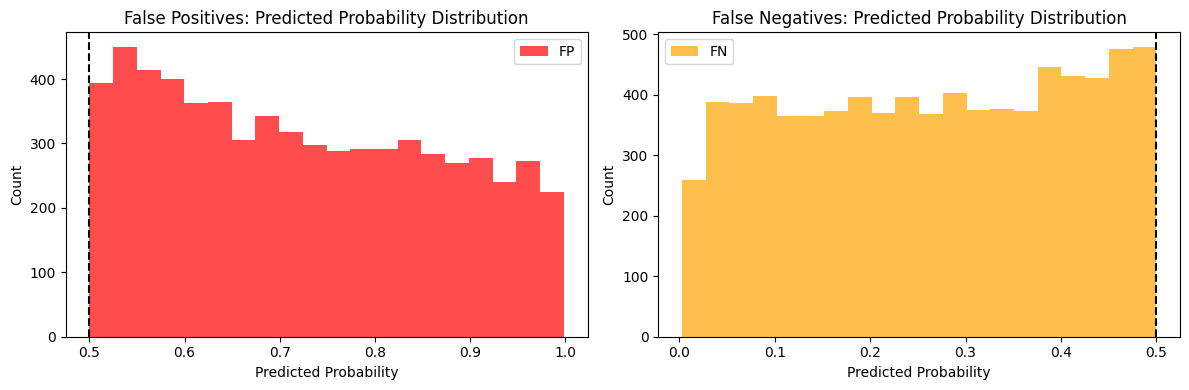

C:\Users\schitta\AppData\Local\Temp\ipykernel_28200\3907232836.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['FP', 'FN', 'TP', 'TN'])
C:\Users\schitta\AppData\Local\Temp\ipykernel_28200\3907232836.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['FP', 'FN', 'TP', 'TN'])
C:\Users\schitta\AppData\Local\Temp\ipykernel_28200\3907232836.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['FP', 'FN', 'TP', 'TN'])
C:\Users\schitta\AppData\Local\Temp\ipykernel_28200\3907232836.py:66: MatplotlibDe

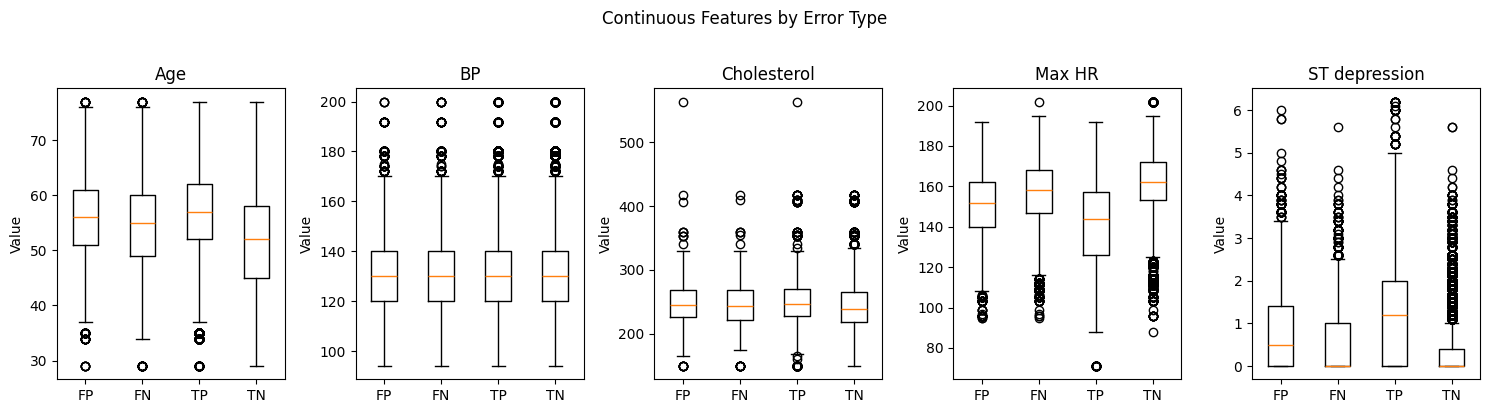


=== Error Rates by Categorical Feature ===

--- Sex ---
error_type  total  error_rate  FP_rate  FN_rate
Sex                                            
0           35845        0.08     0.03     0.06
1           90155        0.13     0.06     0.07

--- Chest pain type ---
error_type       total  error_rate  FP_rate  FN_rate
Chest pain type                                     
1                 5754        0.07     0.01     0.05
2                14872        0.09     0.03     0.07
3                39583        0.10     0.03     0.07
4                65791        0.13     0.07     0.06

--- FBS over 120 ---
error_type     total  error_rate  FP_rate  FN_rate
FBS over 120                                      
0             115936        0.11     0.05     0.06
1              10064        0.11     0.06     0.06

--- EKG results ---
error_type   total  error_rate  FP_rate  FN_rate
EKG results                                     
0            64018        0.11     0.04     0.07
1             

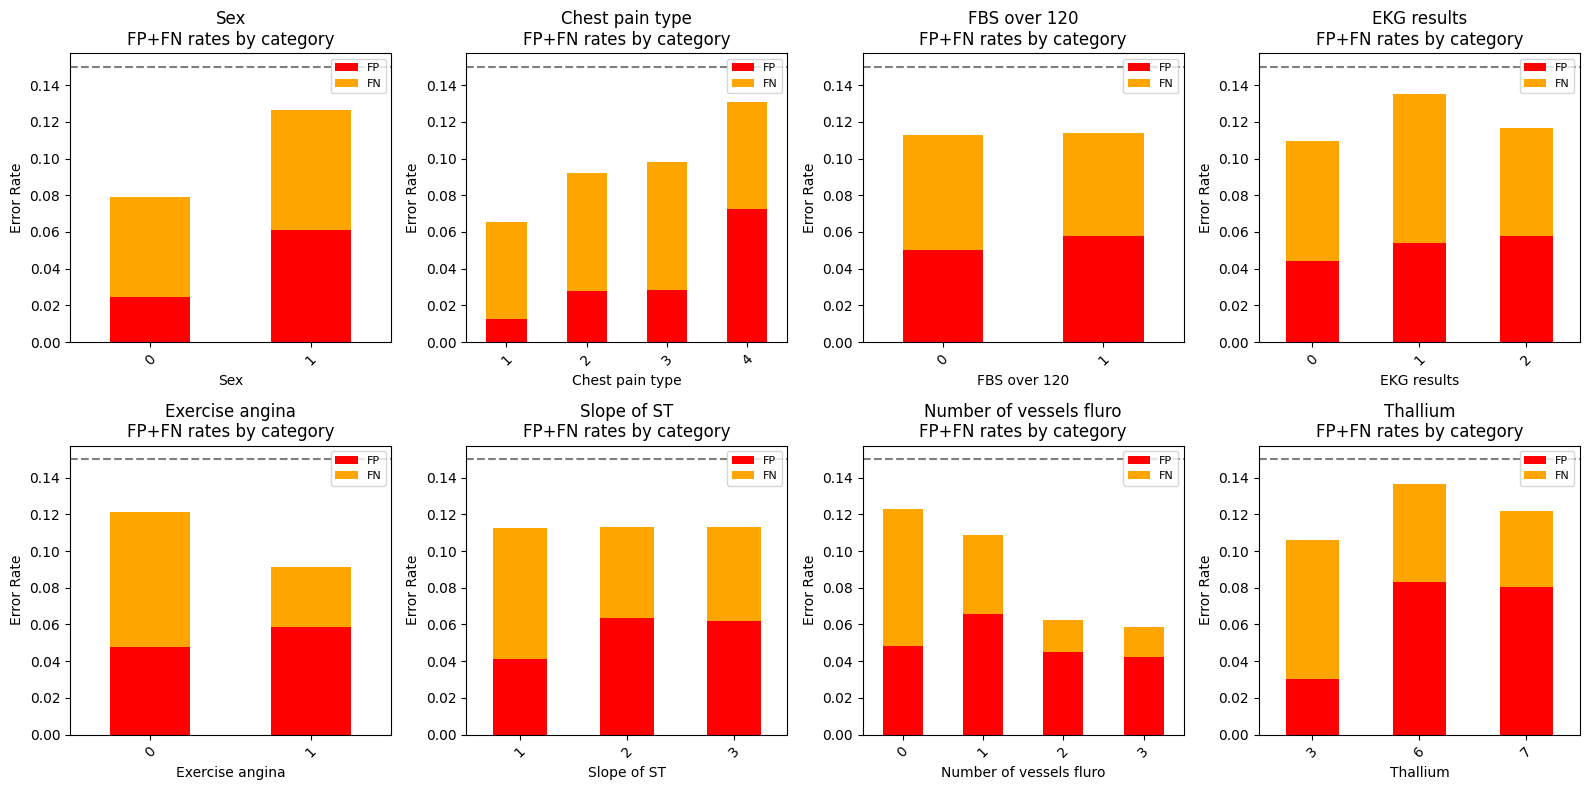


=== Mean Feature Values: FP vs FN ===
               FP_mean  FN_mean  TP_mean  TN_mean  FP_vs_FN_diff
Age              55.37    54.24    56.38    52.27           1.13
BP              130.06   130.40   130.38   130.55          -0.34
Cholesterol     246.96   244.29   248.70   241.99           2.67
Max HR          149.50   155.96   141.43   161.59          -6.46
ST depression     0.80     0.48     1.28     0.30           0.32


In [109]:
# Error Analysis — FP vs FN Patterns
# Classify validation predictions at threshold 0.5

# Get predictions
val_preds_binary = (val_probs >= 0.5).astype(int)
y_valid_bin = (y_valid == 'Presence').astype(int)

# Create error categories
error_df = X_valid.copy()
error_df['y_true'] = y_valid_bin.values
error_df['y_pred'] = val_preds_binary
error_df['pred_prob'] = val_probs

# Label each patient
def classify_error(row):
    if row['y_true'] == 1 and row['y_pred'] == 1:
        return 'TP'
    elif row['y_true'] == 0 and row['y_pred'] == 0:
        return 'TN'
    elif row['y_true'] == 0 and row['y_pred'] == 1:
        return 'FP'
    else:
        return 'FN'

error_df['error_type'] = error_df.apply(classify_error, axis=1)

# Summary counts
print("=== Error Type Distribution ===")
print(error_df['error_type'].value_counts())
print(f"\nTotal errors: {(error_df['error_type'].isin(['FP', 'FN'])).sum()}")
print(f"Error rate: {(error_df['error_type'].isin(['FP', 'FN'])).mean():.2%}")

# Separate error groups
fp_df = error_df[error_df['error_type'] == 'FP']
fn_df = error_df[error_df['error_type'] == 'FN']
tp_df = error_df[error_df['error_type'] == 'TP']
tn_df = error_df[error_df['error_type'] == 'TN']

print(f"\nFP count: {len(fp_df)}, FN count: {len(fn_df)}")

# 1. Predicted probability distribution for errors
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fp_df['pred_prob'], bins=20, alpha=0.7, label='FP', color='red')
axes[0].axvline(x=0.5, color='black', linestyle='--')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('False Positives: Predicted Probability Distribution')
axes[0].legend()

axes[1].hist(fn_df['pred_prob'], bins=20, alpha=0.7, label='FN', color='orange')
axes[1].axvline(x=0.5, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('False Negatives: Predicted Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Continuous features: boxplots comparing error types
fig, axes = plt.subplots(1, len(cont_cols), figsize=(15, 4))

for idx, col in enumerate(cont_cols):
    data_to_plot = [fp_df[col], fn_df[col], tp_df[col], tn_df[col]]
    axes[idx].boxplot(data_to_plot, labels=['FP', 'FN', 'TP', 'TN'])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')

plt.suptitle('Continuous Features by Error Type', y=1.02)
plt.tight_layout()
plt.show()

# 3. Categorical features: error rates per category
print("\n=== Error Rates by Categorical Feature ===")
for col in cat_cols:
    print(f"\n--- {col} ---")
    cross_tab = pd.crosstab(error_df[col], error_df['error_type'])
    cross_tab['total'] = cross_tab.sum(axis=1)
    cross_tab['error_rate'] = (cross_tab.get('FP', 0) + cross_tab.get('FN', 0)) / cross_tab['total']
    cross_tab['FP_rate'] = cross_tab.get('FP', 0) / cross_tab['total']
    cross_tab['FN_rate'] = cross_tab.get('FN', 0) / cross_tab['total']
    print(cross_tab[['total', 'error_rate', 'FP_rate', 'FN_rate']].round(3))
    
    # Flag high error rate subgroups
    high_error = cross_tab[cross_tab['error_rate'] > 0.15]
    if len(high_error) > 0:
        print(f"  ⚠️ Categories with >15% error rate: {list(high_error.index)}")

# 4. Visualize categorical error rates
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    cross_tab = pd.crosstab(error_df[col], error_df['error_type'], normalize='index')
    cross_tab[['FP', 'FN']].plot(kind='bar', ax=axes[idx], stacked=True, color=['red', 'orange'])
    axes[idx].set_title(f'{col}\nFP+FN rates by category')
    axes[idx].set_ylabel('Error Rate')
    axes[idx].axhline(y=0.15, color='black', linestyle='--', alpha=0.5)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# 5. Feature means for FP vs FN
print("\n=== Mean Feature Values: FP vs FN ===")
comparison_df = pd.DataFrame({
    'FP_mean': fp_df[cont_cols].mean(),
    'FN_mean': fn_df[cont_cols].mean(),
    'TP_mean': tp_df[cont_cols].mean(),
    'TN_mean': tn_df[cont_cols].mean(),
})
comparison_df['FP_vs_FN_diff'] = comparison_df['FP_mean'] - comparison_df['FN_mean']
print(comparison_df.round(3))

In [ ]:
## get p's as well along with mean.!
## get the graph above with interaction plots!

## remove noise and maybe try more complex like 3 way interaction or polynomial

## random noise -- didnt change much

In [108]:
# Add random noise feature to train/valid sets
np.random.seed(42)
X_train_noise = X_train.copy()
X_valid_noise = X_valid.copy()
X_train_noise['random_noise'] = np.random.randn(len(X_train))
X_valid_noise['random_noise'] = np.random.randn(len(X_valid))

# Update feature lists
cat_cols_noise = cat_cols.copy()
cont_cols_noise = cont_cols + ['random_noise']

# Build preprocessor with noise feature
preprocessor_noise = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_noise),
    ('num', StandardScaler(), cont_cols_noise),
])

model_noise = Pipeline([
    ('prep', preprocessor_noise),
    ('lr', LogisticRegression(max_iter=1000))
])

model_noise.fit(X_train_noise, y_train)

# Evaluate
train_probs_noise = model_noise.predict_proba(X_train_noise)[:, 1]
val_probs_noise = model_noise.predict_proba(X_valid_noise)[:, 1]

print("=== Model WITH Random Noise Feature ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs_noise):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs_noise):.4f}")

print("\n=== Baseline (No Noise) ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs):.4f}")

# Check coefficient of noise feature
feature_names_noise = model_noise.named_steps['prep'].get_feature_names_out()
coefficients_noise = model_noise.named_steps['lr'].coef_[0]
noise_idx = list(feature_names_noise).index('num__random_noise')
print(f"\nRandom noise coefficient: {coefficients_noise[noise_idx]:.4f}")

=== Model WITH Random Noise Feature ===
Train ROC-AUC: 0.9527
Val ROC-AUC: 0.9537

=== Baseline (No Noise) ===
Train ROC-AUC: 0.9527
Val ROC-AUC: 0.9537

Random noise coefficient: 0.0005


## polynomial feature including interactions

In [25]:
from sklearn.preprocessing import PolynomialFeatures

# Build preprocessor with interaction terms for all feature pairs
# First, separate categorical and numeric processing
cat_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
num_scaler = StandardScaler()

# Fit and transform separately to create interactions
X_train_cat = cat_encoder.fit_transform(X_train[cat_cols])
X_valid_cat = cat_encoder.transform(X_valid[cat_cols])
X_train_num = num_scaler.fit_transform(X_train[cont_cols])
X_valid_num = num_scaler.transform(X_valid[cont_cols])

# Convert sparse to dense if needed
if scipy.sparse.issparse(X_train_cat):
    X_train_cat = X_train_cat.toarray()
    X_valid_cat = X_valid_cat.toarray()

# Combine all features
X_train_all = np.hstack([X_train_cat, X_train_num])
X_valid_all = np.hstack([X_valid_cat, X_valid_num])

# Create interaction terms (degree=2 includes original + interactions)
poly = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)
X_train_interact = poly.fit_transform(X_train_all)
X_valid_interact = poly.transform(X_valid_all)

print(f"Original features: {X_train_all.shape[1]}")
print(f"With interactions: {X_train_interact.shape[1]}")

# Train logistic regression with interactions
lr_interact = LogisticRegression(max_iter=1000)
lr_interact.fit(X_train_interact, y_train)

# Get predictions
train_probs_interact = lr_interact.predict_proba(X_train_interact)[:, 1]
val_probs_interact = lr_interact.predict_proba(X_valid_interact)[:, 1]

# Evaluate
print(f"\n=== Model with All Pairwise Interactions ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs_interact):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs_interact):.4f}")

# Compare with baseline
print(f"\n=== Baseline (No Interactions) ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train, train_probs):.4f}")
print(f"Val ROC-AUC: {roc_auc_score(y_valid, val_probs):.4f}")

print(f"\n=== Improvement ===")
print(f"Train AUC Diff: {roc_auc_score(y_train, train_probs_interact) - roc_auc_score(y_train, train_probs):.4f}")
print(f"Val AUC Diff: {roc_auc_score(y_valid, val_probs_interact) - roc_auc_score(y_valid, val_probs):.4f}")

Original features: 20
With interactions: 1770

=== Model with All Pairwise Interactions ===
Train ROC-AUC: 0.9536
Val ROC-AUC: 0.9540

=== Baseline (No Interactions) ===
Train ROC-AUC: 0.9527
Val ROC-AUC: 0.9537

=== Improvement ===
Train AUC Diff: 0.0009
Val AUC Diff: 0.0003


In [28]:
# Transform test set using the same preprocessor and polynomial features
X_test_cat = cat_encoder.transform(tst_df[cat_cols])
X_test_num = num_scaler.transform(tst_df[cont_cols])

if scipy.sparse.issparse(X_test_cat):
    X_test_cat = X_test_cat.toarray()

# Combine all features
X_test_all = np.hstack([X_test_cat, X_test_num])

# Apply polynomial transformation
X_test_poly = poly.transform(X_test_all)

# Predict probabilities on test set
test_probs_poly = lr_interact.predict_proba(X_test_poly)[:, 1]

# Prepare submission
tst_df['Heart Disease'] = test_probs_poly
sub_df = tst_df[['id', 'Heart Disease']]
sub_df.to_csv('submission_logistic_polynomial_degree3.csv', index=False)

print(f"Submission shape: {sub_df.shape}")
print(sub_df.head())

Submission shape: (270000, 2)
       id  Heart Disease
0  630000           0.93
1  630001           0.00
2  630002           0.99
3  630003           0.00
4  630004           0.29


## different appraoches

## xgboost ranker

In [31]:
import xgboost as xgb

# Prepare binary labels
y_train_bin = (y_train == 'Presence').astype(int)
y_valid_bin = (y_valid == 'Presence').astype(int)

# Preprocess features (same as before)
preprocessor_xgb = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), cont_cols),
])

X_train_xgb = preprocessor_xgb.fit_transform(X_train)
X_valid_xgb = preprocessor_xgb.transform(X_valid)

if scipy.sparse.issparse(X_train_xgb):
    X_train_xgb = X_train_xgb.toarray()
    X_valid_xgb = X_valid_xgb.toarray()

# XGBoost Ranker uses pairwise/listwise ranking to maximize AUC
# We need group information — treat entire dataset as one group (pointwise ranking)
# This effectively optimizes pairwise AUC

xgb_ranker = xgb.XGBRanker(
    objective='rank:pairwise',
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=42,
    tree_method='hist',
    eval_metric='auc',
)

# For XGBRanker, qid defines query groups
# Treat all training samples as one group (single ranking problem)
qid_train = np.zeros(len(X_train_xgb), dtype=int)
qid_valid = np.zeros(len(X_valid_xgb), dtype=int)

xgb_ranker.fit(
    X_train_xgb, y_train_bin,
    qid=qid_train,
    eval_set=[(X_train_xgb, y_train_bin), (X_valid_xgb, y_valid_bin)],
    eval_qid=[qid_train, qid_valid],
    verbose=50,
)

# Get ranking scores (not probabilities — higher = more likely positive)
train_scores_ranker = xgb_ranker.predict(X_train_xgb)
valid_scores_ranker = xgb_ranker.predict(X_valid_xgb)

# Evaluate AUC-ROC (works with any monotonic scores, not just probabilities)
train_auc_ranker = roc_auc_score(y_train_bin, train_scores_ranker)
valid_auc_ranker = roc_auc_score(y_valid_bin, valid_scores_ranker)

print(f"\n{'='*50}")
print(f"=== XGBoost Ranker (rank:pairwise) ===")
print(f"Train ROC-AUC: {train_auc_ranker:.4f}")
print(f"Val ROC-AUC:   {valid_auc_ranker:.4f}")

print(f"\n=== Baseline Logistic Regression ===")
print(f"Train ROC-AUC: {roc_auc_score(y_train_bin, train_probs):.4f}")
print(f"Val ROC-AUC:   {roc_auc_score(y_valid_bin, val_probs):.4f}")

print(f"\n=== Improvement over LR ===")
print(f"Train AUC Diff: {train_auc_ranker - roc_auc_score(y_train_bin, train_probs):+.4f}")
print(f"Val AUC Diff:   {valid_auc_ranker - roc_auc_score(y_valid_bin, val_probs):+.4f}")

[0]	validation_0-auc:0.50000	validation_1-auc:0.50000
[50]	validation_0-auc:0.50000	validation_1-auc:0.50000
[100]	validation_0-auc:0.50000	validation_1-auc:0.50000
[150]	validation_0-auc:0.50000	validation_1-auc:0.50000
[200]	validation_0-auc:0.50000	validation_1-auc:0.50000


KeyboardInterrupt: 

## LibAUC https://libauc.org/ 


In [113]:
# can you implement this https://docs.libauc.org/intro/introduction.html for my dataset. get me train and validation auc roc. i have already installed the package

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from libauc.losses import AUCMLoss
from libauc.optimizers import PESG
from libauc.sampler import DualSampler
from sklearn.metrics import roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [12]:
# Prepare data: reuse the already-split X_train, X_valid, y_train, y_valid
# One-hot encode categoricals + scale numerics -> numpy arrays

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import scipy.sparse

cat_cols_lib = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
cont_cols_lib = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

prep = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_lib),
    ('num', StandardScaler(), cont_cols_lib),
])

X_tr = prep.fit_transform(X_train)
X_va = prep.transform(X_valid)

if scipy.sparse.issparse(X_tr):
    X_tr = X_tr.toarray()
    X_va = X_va.toarray()

# Binary labels: Presence=1, Absence=0
y_tr = (y_train == 'Presence').astype(np.float32).values
y_va = (y_valid == 'Presence').astype(np.float32).values

input_dim = X_tr.shape[1]
print(f"Input dim: {input_dim}, Train: {X_tr.shape[0]}, Valid: {X_va.shape[0]}")
print(f"Positive rate (train): {y_tr.mean():.4f}")

Input dim: 20, Train: 504000, Valid: 126000
Positive rate (train): 0.4483


In [15]:
# Dataset and DataLoader setup

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
        self.targets = y  # DualSampler expects a .targets attribute (numpy array)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_tr, y_tr)
valid_dataset = TabularDataset(X_va, y_va)

BATCH_SIZE = 2048
# Compute real positive rate from training data
pos_rate = float(y_tr.mean())
print(f"Positive rate (train): {pos_rate:.4f}")  # should be ~0.45

# DualSampler ensures balanced pos/neg sampling per batch
sampler = DualSampler(train_dataset, BATCH_SIZE, sampling_rate=pos_rate)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
# For evaluating training AUC without augmentation/sampling bias
train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}")

Positive rate (train): 0.4483
Train batches: 246, Valid batches: 62


In [16]:
y_tr.mean()

np.float32(0.44833928)

In [20]:
y_va.mean()

np.float32(0.44834128)

In [17]:
# Simple MLP model for tabular data

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(0.3),
            ])
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

model = TabularMLP(input_dim, hidden_dims=[128, 64]).to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 11,393


In [18]:
# Training with AUCMLoss + PESG optimizer

loss_fn = AUCMLoss()
optimizer = PESG(model.parameters(),
                 loss_fn=loss_fn,
                 lr=0.1,
                 momentum=0.9,
                 margin=1.0,
                 epoch_decay=2e-3,
                 weight_decay=1e-4)

EPOCHS = 30
decay_epochs = [15, 25]

train_auc_log = []
val_auc_log = []
best_val_auc = 0

for epoch in range(EPOCHS):
    # LR decay
    if epoch in decay_epochs:
        optimizer.update_regularizer(decay_factor=10)
    
    # --- Train ---
    model.train()
    epoch_loss = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = torch.sigmoid(model(X_batch))
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    
    # --- Evaluate ---
    model.eval()
    
    # Train AUC
    train_preds, train_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in train_eval_loader:
            X_batch = X_batch.to(device)
            pred = torch.sigmoid(model(X_batch))
            train_preds.append(pred.cpu().numpy())
            train_labels.append(y_batch.numpy())
    train_preds = np.concatenate(train_preds)
    train_labels = np.concatenate(train_labels)
    train_auc = roc_auc_score(train_labels, train_preds)
    
    # Valid AUC
    val_preds, val_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch = X_batch.to(device)
            pred = torch.sigmoid(model(X_batch))
            val_preds.append(pred.cpu().numpy())
            val_labels.append(y_batch.numpy())
    val_preds = np.concatenate(val_preds)
    val_labels = np.concatenate(val_labels)
    val_auc = roc_auc_score(val_labels, val_preds)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
    
    train_auc_log.append(train_auc)
    val_auc_log.append(val_auc)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {np.mean(epoch_loss):.4f} | "
          f"Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | "
          f"Best Val AUC: {best_val_auc:.4f}")

print(f"\n{'='*50}")
print(f"Best Val AUC: {best_val_auc:.4f} at epoch {best_epoch+1}")
print(f"Baseline LR Val AUC: 0.9537")

Epoch  1/30 | Loss: 0.0892 | Train AUC: 0.9473 | Val AUC: 0.9485 | Best Val AUC: 0.9485
Epoch  2/30 | Loss: 0.0617 | Train AUC: 0.9493 | Val AUC: 0.9504 | Best Val AUC: 0.9504
Epoch  3/30 | Loss: 0.0591 | Train AUC: 0.9503 | Val AUC: 0.9514 | Best Val AUC: 0.9514
Epoch  4/30 | Loss: 0.0579 | Train AUC: 0.9509 | Val AUC: 0.9520 | Best Val AUC: 0.9520
Epoch  5/30 | Loss: 0.0573 | Train AUC: 0.9513 | Val AUC: 0.9524 | Best Val AUC: 0.9524
Epoch  6/30 | Loss: 0.0568 | Train AUC: 0.9516 | Val AUC: 0.9527 | Best Val AUC: 0.9527
Epoch  7/30 | Loss: 0.0565 | Train AUC: 0.9518 | Val AUC: 0.9529 | Best Val AUC: 0.9529
Epoch  8/30 | Loss: 0.0562 | Train AUC: 0.9520 | Val AUC: 0.9531 | Best Val AUC: 0.9531
Epoch  9/30 | Loss: 0.0560 | Train AUC: 0.9522 | Val AUC: 0.9532 | Best Val AUC: 0.9532
Epoch 10/30 | Loss: 0.0559 | Train AUC: 0.9523 | Val AUC: 0.9533 | Best Val AUC: 0.9533
Epoch 11/30 | Loss: 0.0557 | Train AUC: 0.9524 | Val AUC: 0.9534 | Best Val AUC: 0.9534
Epoch 12/30 | Loss: 0.0556 | Tra

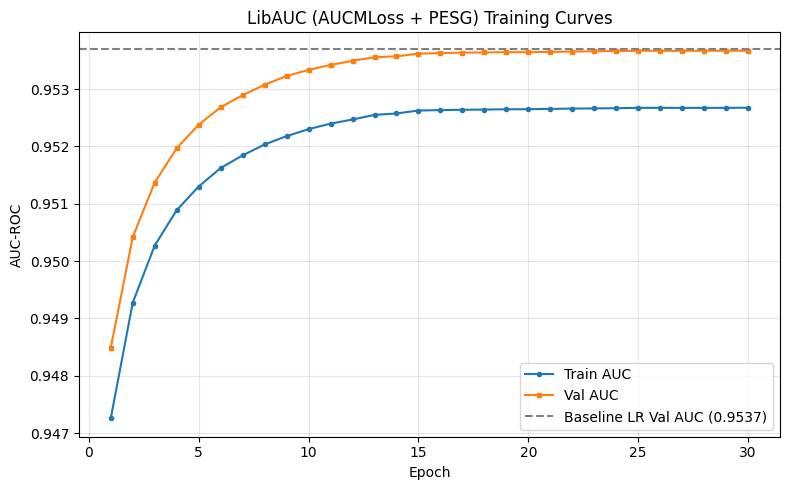

In [19]:
# Plot training curves
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(range(1, EPOCHS+1), train_auc_log, label='Train AUC', marker='o', markersize=3)
ax.plot(range(1, EPOCHS+1), val_auc_log, label='Val AUC', marker='s', markersize=3)
ax.axhline(y=0.9537, color='gray', linestyle='--', label='Baseline LR Val AUC (0.9537)')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC-ROC')
ax.set_title('LibAUC (AUCMLoss + PESG) Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## change this with CV

In [124]:
# LibAUC inference on test set
tst_df = pd.read_csv(path/'test.csv')

# Transform test features using same preprocessor (prep) from training
X_tst = prep.transform(tst_df[cat_cols_lib + cont_cols_lib])
if scipy.sparse.issparse(X_tst):
    X_tst = X_tst.toarray()

# Convert to tensor and predict
X_tst_tensor = torch.tensor(X_tst, dtype=torch.float32)
tst_dataset = torch.utils.data.TensorDataset(X_tst_tensor)
tst_loader = DataLoader(tst_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model.eval()
test_preds = []
with torch.no_grad():
    for (X_batch,) in tst_loader:
        X_batch = X_batch.to(device)
        pred = torch.sigmoid(model(X_batch))
        test_preds.append(pred.cpu().numpy())

test_preds = np.concatenate(test_preds).squeeze()

# Save submission
sub_df = pd.DataFrame({'id': tst_df['id'], 'Heart Disease': test_preds})
sub_df.to_csv('submission_libauc_aucmloss.csv', index=False)
print(f"Submission shape: {sub_df.shape}")
print(sub_df.head())

Submission shape: (270000, 2)
       id  Heart Disease
0  630000           0.92
1  630001           0.00
2  630002           0.99
3  630003           0.00
4  630004           0.47


## AUC-Maximizing Ensemble (LeDell et al. 2016)

**Paper**: "AUC-Maximizing Ensembles through Metalearning" — LeDell, van der Laan, Petersen (2016)

**Approach**: Train diverse base learners with K-fold CV, collect out-of-fold predictions, then find ensemble weights via constrained optimization that **directly maximizes AUC** (not log-loss). Weights are non-negative and sum to 1.

In [129]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize
import numpy as np
import scipy.sparse

# ── Feature definitions (same as before) ──
cat_cols_ens = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
cont_cols_ens = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# ── Base learner definitions ──
# Each gets its own preprocessing pipeline
def make_pipeline(model, cat_cols, cont_cols):
    prep = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), cont_cols),
    ])
    return Pipeline([('prep', prep), ('model', model)])

base_learners = {
    'lr':   make_pipeline(LogisticRegression(max_iter=1000, C=1.0), cat_cols_ens, cont_cols_ens),
    'lr_l1': make_pipeline(LogisticRegression(max_iter=1000, C=0.5, penalty='l1', solver='saga'), cat_cols_ens, cont_cols_ens),
    'rf':   make_pipeline(RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1), cat_cols_ens, cont_cols_ens),
    'et':   make_pipeline(ExtraTreesClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1), cat_cols_ens, cont_cols_ens),
    'gbm':  make_pipeline(GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.8, random_state=42), cat_cols_ens, cont_cols_ens),
    'knn':  make_pipeline(KNeighborsClassifier(n_neighbors=50, n_jobs=-1), cat_cols_ens, cont_cols_ens),
    'mlp':  make_pipeline(MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, early_stopping=True, random_state=42), cat_cols_ens, cont_cols_ens),
}

print(f"Base learners: {list(base_learners.keys())}")

Base learners: ['lr', 'lr_l1', 'rf', 'et', 'gbm', 'knn', 'mlp']


In [131]:
# ── Step 1: K-fold CV to generate out-of-fold predictions ──
# Uses X_train/y_train (the 80% training split already defined)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X_ens = X_train[cat_cols_ens + cont_cols_ens]
y_ens = y_train
y_ens_bin = (y_ens == 'Presence').astype(int)

n_models = len(base_learners)
model_names = list(base_learners.keys())

# Out-of-fold predictions matrix: (n_train_samples, n_models)
oof_preds = np.zeros((len(X_ens), n_models))
# Full-training predictions for test inference: list of fitted models per fold
fold_models = {name: [] for name in model_names}

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_ens, y_ens_bin)):
    X_fold_train = X_ens.iloc[train_idx]
    y_fold_train = y_ens.iloc[train_idx]
    X_fold_val = X_ens.iloc[val_idx]
    y_fold_val = y_ens.iloc[val_idx]
    for m_idx, (name, pipe) in enumerate(base_learners.items()):
        from sklearn.base import clone
        model_clone = clone(pipe)
        y_fit = (y_fold_train == 'Presence').astype(int)
        model_clone.fit(X_fold_train, y_fit)
        
        # Out-of-fold predictions
        oof_preds[val_idx, m_idx] = model_clone.predict_proba(X_fold_val)[:, 1]
        
        # Save fitted model for test inference
        fold_models[name].append(model_clone)
    
    # Per-fold AUC for each base learner
    fold_aucs = [roc_auc_score(y_ens_bin.iloc[val_idx], oof_preds[val_idx, m]) for m in range(n_models)]
    auc_str = '  '.join([f'{model_names[m]}: {fold_aucs[m]:.4f}' for m in range(n_models)])
    print(f"Fold {fold_idx+1}/{N_FOLDS}: {auc_str}")

# Overall OOF AUC per base learner
print(f"\n{'='*60}")
print("Overall OOF AUC per base learner:")
for m_idx, name in enumerate(model_names):
    auc = roc_auc_score(y_ens_bin, oof_preds[:, m_idx])
    print(f"  {name:8s}: {auc:.4f}")

c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fold 1/5: lr: 0.9523  lr_l1: 0.9523  rf: 0.9480  et: 0.9431  gbm: 0.9542  knn: 0.9469  mlp: 0.9526


c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fold 2/5: lr: 0.9525  lr_l1: 0.9525  rf: 0.9479  et: 0.9425  gbm: 0.9544  knn: 0.9467  mlp: 0.9525


c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fold 3/5: lr: 0.9527  lr_l1: 0.9527  rf: 0.9482  et: 0.9430  gbm: 0.9545  knn: 0.9470  mlp: 0.9526


c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fold 4/5: lr: 0.9527  lr_l1: 0.9527  rf: 0.9480  et: 0.9432  gbm: 0.9545  knn: 0.9472  mlp: 0.9529


c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\schitta\Downloads\ml-experiments\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fold 5/5: lr: 0.9532  lr_l1: 0.9532  rf: 0.9482  et: 0.9433  gbm: 0.9550  knn: 0.9478  mlp: 0.9536

Overall OOF AUC per base learner:
  lr      : 0.9527
  lr_l1   : 0.9527
  rf      : 0.9480
  et      : 0.9430
  gbm     : 0.9545
  knn     : 0.9471
  mlp     : 0.9527


In [132]:
# ── Step 2: AUC-maximizing metalearner (constrained optimization) ──
# Find weights w_i >= 0, sum(w_i) = 1 that maximize AUC of weighted combo

def neg_auc(weights, oof_matrix, y_true):
    """Negative AUC (to minimize)."""
    combined = oof_matrix @ weights
    return -roc_auc_score(y_true, combined)

# Constraints: weights sum to 1, each weight >= 0
n = n_models
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
bounds = [(0.0, 1.0)] * n

# Multi-start optimization (AUC is non-convex, so try several initializations)
best_result = None
best_auc = -1

# Start points: uniform, each-model-solo, random
starts = [np.ones(n) / n]  # uniform
for i in range(n):
    w = np.zeros(n)
    w[i] = 1.0
    starts.append(w)
np.random.seed(42)
for _ in range(20):
    w = np.random.dirichlet(np.ones(n))
    starts.append(w)

for w0 in starts:
    result = minimize(neg_auc, w0, args=(oof_preds, y_ens_bin.values),
                      method='SLSQP', bounds=bounds, constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-12})
    if -result.fun > best_auc:
        best_auc = -result.fun
        best_result = result

optimal_weights = best_result.x

print("AUC-Maximizing Ensemble Weights:")
print("-" * 40)
for name, w in zip(model_names, optimal_weights):
    print(f"  {name:8s}: {w:.4f}")
print(f"\nOOF AUC (uniform avg):    {roc_auc_score(y_ens_bin, oof_preds.mean(axis=1)):.4f}")
print(f"OOF AUC (AUC-optimized):  {best_auc:.4f}")
print(f"Baseline LR Val AUC:      0.9537")

AUC-Maximizing Ensemble Weights:
----------------------------------------
  lr      : 0.0000
  lr_l1   : 0.0000
  rf      : 0.0000
  et      : 0.0000
  gbm     : 1.0000
  knn     : 0.0000
  mlp     : 0.0000

OOF AUC (uniform avg):    0.9527
OOF AUC (AUC-optimized):  0.9545
Baseline LR Val AUC:      0.9537


In [133]:
# ── Step 3: Validate ensemble on held-out X_valid/y_valid ──
X_val_ens = X_valid[cat_cols_ens + cont_cols_ens]
y_val_bin = (y_valid == 'Presence').astype(int)

# Each base learner's val prediction = average of its K fold models
val_preds_per_model = np.zeros((len(X_val_ens), n_models))
for m_idx, name in enumerate(model_names):
    fold_preds = np.zeros((len(X_val_ens), N_FOLDS))
    for k, fitted_model in enumerate(fold_models[name]):
        fold_preds[:, k] = fitted_model.predict_proba(X_val_ens)[:, 1]
    val_preds_per_model[:, m_idx] = fold_preds.mean(axis=1)

# Weighted ensemble prediction
val_ensemble_preds = val_preds_per_model @ optimal_weights

print("Validation AUC per base learner:")
print("-" * 40)
for m_idx, name in enumerate(model_names):
    auc = roc_auc_score(y_val_bin, val_preds_per_model[:, m_idx])
    print(f"  {name:8s}: {auc:.4f}")

print(f"\nVal AUC (uniform avg):    {roc_auc_score(y_val_bin, val_preds_per_model.mean(axis=1)):.4f}")
print(f"Val AUC (AUC-optimized):  {roc_auc_score(y_val_bin, val_ensemble_preds):.4f}")
print(f"Baseline LR Val AUC:      0.9537")


Validation AUC per base learner:
----------------------------------------
  lr      : 0.9537
  lr_l1   : 0.9537
  rf      : 0.9487
  et      : 0.9434
  gbm     : 0.9556
  knn     : 0.9487
  mlp     : 0.9540

Val AUC (uniform avg):    0.9535
Val AUC (AUC-optimized):  0.9556
Baseline LR Val AUC:      0.9537


In [134]:
# ── Step 4: Test inference ──
tst_df = pd.read_csv(path/'test.csv')
X_tst_ens = tst_df[cat_cols_ens + cont_cols_ens]

# Each base learner's test prediction = average of its K fold models
tst_preds_per_model = np.zeros((len(X_tst_ens), n_models))
for m_idx, name in enumerate(model_names):
    fold_preds = np.zeros((len(X_tst_ens), N_FOLDS))
    for k, fitted_model in enumerate(fold_models[name]):
        fold_preds[:, k] = fitted_model.predict_proba(X_tst_ens)[:, 1]
    tst_preds_per_model[:, m_idx] = fold_preds.mean(axis=1)

# Weighted ensemble
tst_ensemble_preds = tst_preds_per_model @ optimal_weights

# Save submission
sub_df = pd.DataFrame({'id': tst_df['id'], 'Heart Disease': tst_ensemble_preds})
sub_df.to_csv('submission_auc_ensemble_ledell.csv', index=False)
print(f"Submission shape: {sub_df.shape}")
print(sub_df.head())


Submission shape: (270000, 2)
       id  Heart Disease
0  630000           0.92
1  630001           0.01
2  630002           0.98
3  630003           0.01
4  630004           0.24


## polynomial logistic with regularization 